# Estimation Theory Concepts — Acoustic Source Localization

This notebook builds up the estimation theory behind the acoustic localization engine,
concept by concept, in the order they appear in the implementation.
Each section has a brief refresher, the relevant math, and a working code illustration.

**Audience:** Someone who has taken an estimation theory course but needs a practical refresh.

**Teaching style (section 8 onward):** each concept is anchored to a channel-coding /
comms idea you already own, built from scratch, and stress-tested ("break it") so the
intuition sticks rather than staying a familiar term.

---
**Concepts covered:**
1. TDOA — what it measures and the hyperbolic geometry
2. Gauss-Newton for nonlinear least squares
3. TDOA noise model — why measurements are correlated
4. Weighted least squares — the MLE solution
5. Fisher Information Matrix and the CRLB
6. Confidence ellipse — eigendecomposition and chi-squared threshold
7. GDOP — geometric dilution of precision
8. Weighted estimation as Maximum-Ratio Combining (Phase 1.5 · step A2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Ellipse
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

---
## 1. TDOA — Time Difference of Arrival

### What is it?

A source emits a sound pulse at time $t_0$ from position $\mathbf{x} = [x, y]$.
Sensor $i$ at position $\mathbf{s}_i$ receives it at:

$$\tau_i = \frac{\|\mathbf{x} - \mathbf{s}_i\|}{c}$$

We don't know $t_0$, so we can't use absolute TOA. Instead we measure **differences**
relative to a reference sensor (sensor 0):

$$\Delta\tau_i = \tau_i - \tau_0 = \frac{\|\mathbf{x} - \mathbf{s}_i\| - \|\mathbf{x} - \mathbf{s}_0\|}{c}$$

This eliminates $t_0$. Each $\Delta\tau_i$ constrains the source to lie on a **hyperboloid**
with foci at $\mathbf{s}_i$ and $\mathbf{s}_0$. The intersection of $N-1$ hyperboloids
gives the source position.

### Key insight
TDOA tells you the *range difference*, not the range itself. With N sensors you get N-1
independent TDOA measurements (one per non-reference sensor).

Range to s0: 144.22 m
Range to s1: 169.71 m
TDOA:        74.2961 ms
Range diff:  25.484 m


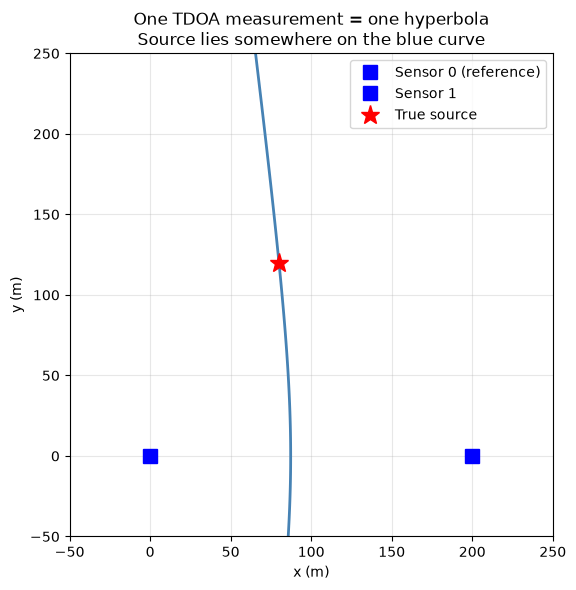

In [2]:
# Illustrate: plot a single hyperbola defined by one TDOA measurement
c = 343.0  # speed of sound m/s

s0 = np.array([0.0,   0.0])   # reference sensor
s1 = np.array([200.0, 0.0])   # sensor 1
true_src = np.array([80.0, 120.0])

# True TDOA (no noise)
r0 = np.linalg.norm(true_src - s0)
r1 = np.linalg.norm(true_src - s1)
tdoa_true = (r1 - r0) / c   # seconds
range_diff = tdoa_true * c  # metres
print(f"Range to s0: {r0:.2f} m")
print(f"Range to s1: {r1:.2f} m")
print(f"TDOA:        {tdoa_true*1000:.4f} ms")
print(f"Range diff:  {range_diff:.3f} m")

# Plot the hyperbola: all points where ||x-s1|| - ||x-s0|| = range_diff
grid = np.linspace(-50, 250, 400)
X, Y = np.meshgrid(grid, grid)
R0 = np.sqrt((X - s0[0])**2 + (Y - s0[1])**2)
R1 = np.sqrt((X - s1[0])**2 + (Y - s1[1])**2)

fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(X, Y, R1 - R0, levels=[range_diff], colors='steelblue', linewidths=2)
ax.plot(*s0, 'bs', markersize=10, label='Sensor 0 (reference)')
ax.plot(*s1, 'bs', markersize=10, label='Sensor 1')
ax.plot(*true_src, 'r*', markersize=14, label='True source')
ax.set_xlim(-50, 250); ax.set_ylim(-50, 250)
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('One TDOA measurement = one hyperbola\nSource lies somewhere on the blue curve')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

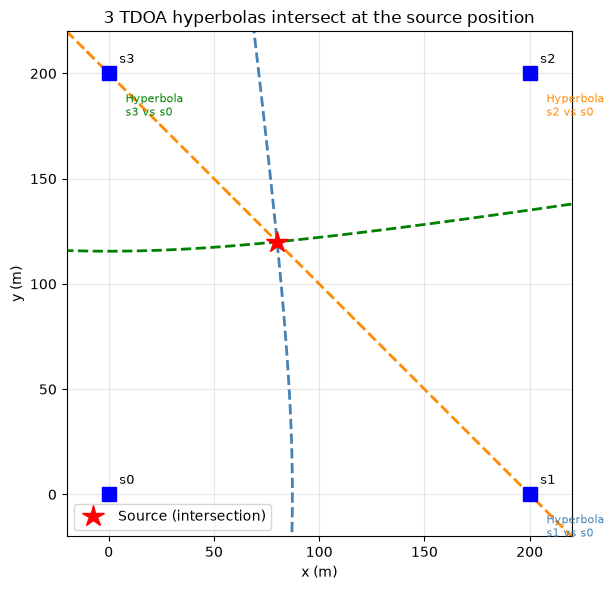

In [3]:
# With 4 sensors, 3 hyperbolas intersect at the source position
sensors = np.array([
    [  0.0,   0.0],
    [200.0,   0.0],
    [200.0, 200.0],
    [  0.0, 200.0],
])

R_ref = np.sqrt((X - sensors[0,0])**2 + (Y - sensors[0,1])**2)

colors = ['steelblue', 'darkorange', 'green']
fig, ax = plt.subplots(figsize=(7, 6))

for i, (s, col) in enumerate(zip(sensors[1:], colors)):
    r_i = np.sqrt((X - s[0])**2 + (Y - s[1])**2)
    rd  = (np.linalg.norm(true_src - s) - np.linalg.norm(true_src - sensors[0]))
    ax.contour(X, Y, r_i - R_ref, levels=[rd], colors=col,
               linewidths=2, linestyles='--')
    ax.annotate(f'Hyperbola\ns{i+1} vs s0', xy=s, fontsize=8, color=col,
                xytext=(s[0]+8, s[1]-20))

for i, s in enumerate(sensors):
    ax.plot(*s, 'bs', markersize=10)
    ax.annotate(f's{i}', xy=s, xytext=(s[0]+5, s[1]+5), fontsize=9)

ax.plot(*true_src, 'r*', markersize=16, label='Source (intersection)', zorder=5)
ax.set_xlim(-20, 220); ax.set_ylim(-20, 220)
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('3 TDOA hyperbolas intersect at the source position')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Gauss-Newton for Nonlinear Least Squares

### The problem
We want to find $\mathbf{x}$ such that the predicted TDOA matches the measured TDOA.
Define the residual for sensor $i$:

$$r_i(\mathbf{x}) = \underbrace{(\|\mathbf{x} - \mathbf{s}_i\| - \|\mathbf{x} - \mathbf{s}_0\|)}_{\text{predicted range diff}} - \underbrace{c \cdot \Delta\tau_i}_{\text{measured range diff}}$$

We want $\min_{\mathbf{x}} \|\mathbf{r}(\mathbf{x})\|^2$. This is **nonlinear** in $\mathbf{x}$
because of the norms — no closed-form solution.

### Gauss-Newton linearisation
Linearise $\mathbf{r}$ around current estimate $\mathbf{x}_k$:

$$\mathbf{r}(\mathbf{x}_k + \boldsymbol{\delta}) \approx \mathbf{r}(\mathbf{x}_k) + \mathbf{J}\boldsymbol{\delta}$$

where $\mathbf{J}$ is the Jacobian $\partial \mathbf{r}/\partial \mathbf{x}$. Minimising
the linearised problem gives the **normal equations**:

$$\boldsymbol{\delta}^* = -(\mathbf{J}^T \mathbf{J})^{-1} \mathbf{J}^T \mathbf{r}$$

Update: $\mathbf{x}_{k+1} = \mathbf{x}_k + \boldsymbol{\delta}^*$. Repeat until $\|\boldsymbol{\delta}^*\| < \epsilon$.

### The Jacobian
$$J_{ij} = \frac{\partial r_i}{\partial x_j} = \frac{(x_j - s_{ij})}{\|\mathbf{x} - \mathbf{s}_i\|} - \frac{(x_j - s_{0j})}{\|\mathbf{x} - \mathbf{s}_0\|}$$

In words: the unit vector from $\mathbf{x}$ toward $\mathbf{s}_i$, minus the unit vector
toward $\mathbf{s}_0$.

Iterations to converge: 4
Start:  [100. 100.]
End:    [ 80. 120.]
True:   [ 80. 120.]
Error:  0.0000 mm


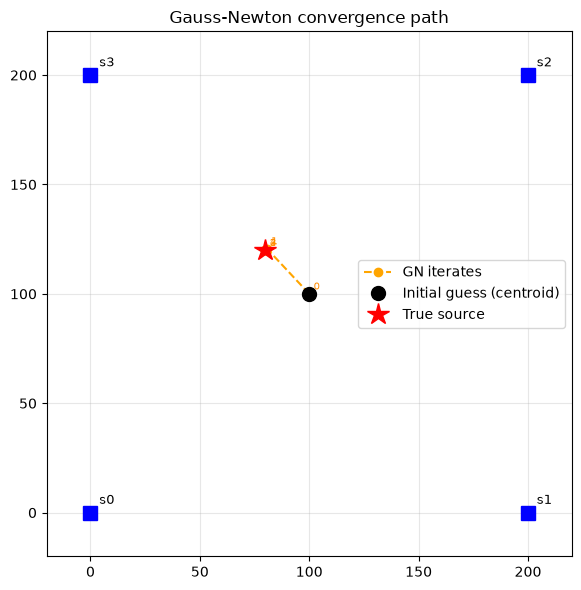

In [4]:
# Illustrate Gauss-Newton convergence: track x at each iteration
def gauss_newton_steps(tdoa_meas, sensor_positions, c=343.0, max_iter=20):
    s0 = sensor_positions[0]
    S  = sensor_positions[1:]
    d  = tdoa_meas * c
    x  = sensor_positions.mean(axis=0).copy().astype(float)
    path = [x.copy()]
    for _ in range(max_iter):
        r0 = np.linalg.norm(x - s0)
        ri = np.linalg.norm(x - S, axis=1)
        res = (ri - r0) - d
        J   = (x - S) / ri[:, None] - (x - s0) / r0
        delta = np.linalg.solve(J.T @ J, J.T @ (-res))
        x = x + delta
        path.append(x.copy())
        if np.linalg.norm(delta) < 1e-8:
            break
    return np.array(path)

# Noiseless TDOA
tdoa_noiseless = np.array([
    (np.linalg.norm(true_src - sensors[i]) - np.linalg.norm(true_src - sensors[0])) / c
    for i in range(1, 4)
])

path = gauss_newton_steps(tdoa_noiseless, sensors)
print(f"Iterations to converge: {len(path)-1}")
print(f"Start:  {path[0]}")
print(f"End:    {path[-1]}")
print(f"True:   {true_src}")
print(f"Error:  {np.linalg.norm(path[-1] - true_src)*1000:.4f} mm")

fig, ax = plt.subplots(figsize=(7, 6))
for i, s in enumerate(sensors):
    ax.plot(*s, 'bs', markersize=10)
    ax.annotate(f's{i}', xy=s, xytext=(s[0]+4, s[1]+4), fontsize=9)
ax.plot(path[:,0], path[:,1], 'o--', color='orange', markersize=6, label='GN iterates')
for k, p in enumerate(path):
    ax.annotate(str(k), xy=p, fontsize=7, color='darkorange',
                xytext=(p[0]+2, p[1]+2))
ax.plot(*path[0], 'ko', markersize=10, label='Initial guess (centroid)')
ax.plot(*true_src, 'r*', markersize=16, label='True source', zorder=5)
ax.set_xlim(-20, 220); ax.set_ylim(-20, 220)
ax.set_aspect('equal')
ax.set_title('Gauss-Newton convergence path')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. TDOA Noise Model — Why Measurements Are Correlated

Each sensor has independent timing noise: $\eta_i \sim \mathcal{N}(0, \sigma_\tau^2)$.
The noisy TOA is $\tilde{\tau}_i = \tau_i + \eta_i$.

The TDOA measurement is:
$$\widetilde{\Delta\tau}_i = \tilde{\tau}_i - \tilde{\tau}_0 = \Delta\tau_i + (\eta_i - \eta_0)$$

So the TDOA noise is $\nu_i = \eta_i - \eta_0$.  
Since **sensor 0 appears in every TDOA**, any two TDOA measurements share $\eta_0$:

$$\text{Cov}(\nu_i, \nu_j) = \text{Cov}(\eta_i - \eta_0,\ \eta_j - \eta_0) = \begin{cases} 2\sigma_\tau^2 & i = j \\ \sigma_\tau^2 & i \neq j \end{cases}$$

In matrix form, the TDOA noise covariance (in time units) is:

$$\mathbf{C}_\tau = \sigma_\tau^2 (\mathbf{I} + \mathbf{1}\mathbf{1}^T)$$

where $\mathbf{1}$ is the all-ones vector of length $N-1$.  
In **range units** ($\sigma_r = c \sigma_\tau$):

$$\mathbf{C}_r = \sigma_r^2 \mathbf{M}, \quad \mathbf{M} = \mathbf{I} + \mathbf{1}\mathbf{1}^T$$

In [5]:
# Show the correlation structure of TDOA noise empirically
N_sensors = 4
N_tdoa    = N_sensors - 1
sigma_tau = 1e-4   # 0.1 ms
n_trials  = 10000
rng       = np.random.default_rng(0)

# Simulate TOA noise and compute TDOA noise
eta = rng.normal(0, sigma_tau, size=(n_trials, N_sensors))
nu  = eta[:, 1:] - eta[:, [0]]   # TDOA noise, shape (n_trials, N_tdoa)

empirical_cov = np.cov(nu.T)
theoretical_cov = sigma_tau**2 * (np.eye(N_tdoa) + np.ones((N_tdoa, N_tdoa)))

print("Empirical TDOA noise covariance (x 1e-8):")
print(np.round(empirical_cov * 1e8, 2))
print()
print("Theoretical: sigma_tau^2 * (I + ones) (x 1e-8):")
print(np.round(theoretical_cov * 1e8, 2))
print()
print("Diagonal = 2*sigma_tau^2 (each TDOA is diff of 2 independent noises)")
print("Off-diagonal = sigma_tau^2 (shared sensor-0 noise)")

Empirical TDOA noise covariance (x 1e-8):
[[2.01 1.   0.98]
 [1.   1.98 0.96]
 [0.98 0.96 1.99]]

Theoretical: sigma_tau^2 * (I + ones) (x 1e-8):
[[2. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

Diagonal = 2*sigma_tau^2 (each TDOA is diff of 2 independent noises)
Off-diagonal = sigma_tau^2 (shared sensor-0 noise)


---
## 4. Weighted Least Squares — The MLE Solution

### Why unweighted LS is wrong here

Standard (unweighted) least squares assumes i.i.d. noise: $\mathbf{r} \sim \mathcal{N}(0, \sigma^2 \mathbf{I})$.
But we just showed TDOA noise has covariance $\sigma_r^2 \mathbf{M}$ with off-diagonal terms.
Ignoring this gives a biased covariance estimate and an ellipse that is too small.

### The correct MLE (= Weighted LS)

With noise covariance $\mathbf{C} = \sigma_r^2 \mathbf{M}$, the MLE objective is:

$$\min_{\mathbf{x}} \mathbf{r}^T \mathbf{C}^{-1} \mathbf{r} = \min_{\mathbf{x}} \mathbf{r}^T \mathbf{M}^{-1} \mathbf{r}$$

The weighted Gauss-Newton step becomes:

$$\boldsymbol{\delta}^* = -(\mathbf{J}^T \mathbf{M}^{-1} \mathbf{J})^{-1} \mathbf{J}^T \mathbf{M}^{-1} \mathbf{r}$$

### Sherman-Morrison for $\mathbf{M}^{-1}$

$\mathbf{M} = \mathbf{I} + \mathbf{1}\mathbf{1}^T$ is a rank-1 update of the identity.
Sherman-Morrison gives:

$$\mathbf{M}^{-1} = \mathbf{I} - \frac{\mathbf{1}\mathbf{1}^T}{1 + N - 1} = \mathbf{I} - \frac{1}{N}\mathbf{1}\mathbf{1}^T$$

For $N = 4$ sensors: $\mathbf{M}^{-1} = \mathbf{I} - 0.25 \cdot \mathbf{1}\mathbf{1}^T$

In [6]:
# Verify Sherman-Morrison numerically
N = 4
M    = np.eye(N-1) + np.ones((N-1, N-1))
Minv_sm   = np.eye(N-1) - np.ones((N-1, N-1)) / N
Minv_true = np.linalg.inv(M)

print("M:")
print(M)
print()
print("M^{-1} via Sherman-Morrison (I - ones/N):")
print(np.round(Minv_sm, 4))
print()
print("M^{-1} via np.linalg.inv:")
print(np.round(Minv_true, 4))
print()
print("M @ M^{-1} (should be I):")
print(np.round(M @ Minv_sm, 10))

M:
[[2. 1. 1.]
 [1. 2. 1.]
 [1. 1. 2.]]

M^{-1} via Sherman-Morrison (I - ones/N):
[[ 0.75 -0.25 -0.25]
 [-0.25  0.75 -0.25]
 [-0.25 -0.25  0.75]]

M^{-1} via np.linalg.inv:
[[ 0.75 -0.25 -0.25]
 [-0.25  0.75 -0.25]
 [-0.25 -0.25  0.75]]

M @ M^{-1} (should be I):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


In [7]:
# Compare unweighted vs weighted LS covariance empirically
# Run many noisy trials, record (1) unweighted cov estimate, (2) weighted cov estimate
# and compare to empirical position scatter

import sys; sys.path.insert(0, '..')
from engine.tdoa import compute_tdoa_measurements
from engine.localizer import GaussNewtonTDOA
from engine.propagation import SPEED_OF_SOUND

src    = np.array([100.0, 100.0])
sigma_r = SPEED_OF_SOUND * sigma_tau
localizer = GaussNewtonTDOA()
rng2 = np.random.default_rng(42)
n_mc = 2000

estimates = []
for _ in range(n_mc):
    tdoa = compute_tdoa_measurements(src, sensors, noise_std_s=sigma_tau, rng=rng2)
    est, _ = localizer.estimate(tdoa, sensors)
    estimates.append(est)
estimates = np.array(estimates)

empirical_pos_cov = np.cov(estimates.T)
_, raw_cov = localizer.estimate(tdoa_noiseless, sensors)   # geometry-only cov
predicted_cov = raw_cov * sigma_r**2

print("Empirical position covariance from 2000 Monte Carlo trials (mm^2):")
print(np.round(empirical_pos_cov * 1e6, 2))
print()
print("Weighted LS predicted covariance (mm^2):")
print(np.round(predicted_cov * 1e6, 2))
print()
print("Ratio (empirical / predicted) — should be ~1.0:")
print(np.round(empirical_pos_cov / predicted_cov, 3))

Empirical position covariance from 2000 Monte Carlo trials (mm^2):
[[589.83 -13.11]
 [-13.11 607.64]]

Weighted LS predicted covariance (mm^2):
[[594.46  17.31]
 [ 17.31 594.46]]

Ratio (empirical / predicted) — should be ~1.0:
[[ 0.992 -0.757]
 [-0.757  1.022]]


---
## 5. Fisher Information Matrix and the CRLB

### What is the CRLB?

The **Cramér-Rao Lower Bound** says: for any unbiased estimator $\hat{\mathbf{x}}$,

$$\text{Cov}(\hat{\mathbf{x}}) \succeq \mathbf{F}^{-1}$$

where $\mathbf{F}$ is the **Fisher Information Matrix (FIM)**.  
No unbiased estimator can achieve lower variance than $\mathbf{F}^{-1}$.

### FIM for linearised TDOA

For Gaussian noise with covariance $\mathbf{C}$, the FIM evaluated at $\mathbf{x}$ is:

$$\mathbf{F} = \mathbf{J}^T \mathbf{C}^{-1} \mathbf{J} = \frac{1}{\sigma_r^2} \mathbf{J}^T \mathbf{M}^{-1} \mathbf{J}$$

So:
$$\mathbf{F}^{-1} = \sigma_r^2 (\mathbf{J}^T \mathbf{M}^{-1} \mathbf{J})^{-1}$$

This is exactly what our weighted GN returns as the covariance estimate.
The MLE achieves the CRLB asymptotically — our estimator is **efficient**.

### Connection to your channel coding background

The FIM here is the direct analog of the inverse noise covariance in a linear AWGN channel.
$\mathbf{J}$ plays the role of the channel matrix $\mathbf{H}$ — it maps position
perturbations to TDOA perturbations. $\mathbf{J}^T \mathbf{M}^{-1} \mathbf{J}$ is the
matched-filter information accumulation, exactly as $\mathbf{H}^T \mathbf{C}_n^{-1} \mathbf{H}$
in a MIMO detection problem.

In [8]:
# Compute FIM and CRLB at several positions across the sensor array
# Show how the bound varies with geometry

def compute_fim(pos, sensor_positions, sigma_r, c=343.0):
    s0 = sensor_positions[0]
    S  = sensor_positions[1:]
    N  = len(sensor_positions)
    r0 = np.linalg.norm(pos - s0)
    ri = np.linalg.norm(pos - S, axis=1)
    J  = (pos - S) / ri[:, None] - (pos - s0) / r0
    Minv = np.eye(N-1) - np.ones((N-1, N-1)) / N
    F = (J.T @ Minv @ J) / sigma_r**2
    return F

test_positions = [
    ("Centre",     np.array([100.0, 100.0])),
    ("Near edge",  np.array([ 15.0, 100.0])),
    ("Near corner",np.array([ 20.0,  20.0])),
    ("Off-centre", np.array([140.0,  70.0])),
]

print(f"{'Position':<15} | {'CRLB std x (mm)':>16} | {'CRLB std y (mm)':>16} | {'CRLB area (mm^2)':>16}")
print("-" * 72)
for name, pos in test_positions:
    F    = compute_fim(pos, sensors, sigma_r)
    crlb = np.linalg.inv(F)
    sx   = np.sqrt(crlb[0,0]) * 1000
    sy   = np.sqrt(crlb[1,1]) * 1000
    area = np.pi * sx * sy
    print(f"{name:<15} | {sx:>16.2f} | {sy:>16.2f} | {area:>16.2f}")

Position        |  CRLB std x (mm) |  CRLB std y (mm) | CRLB area (mm^2)
------------------------------------------------------------------------
Centre          |            24.25 |            24.25 |          1848.03
Near edge       |            33.36 |            22.10 |          2316.74
Near corner     |            26.99 |            26.99 |          2288.54
Off-centre      |            25.25 |            24.17 |          1916.98


---
## 6. Confidence Ellipse — Eigendecomposition and Chi-Squared Threshold

### From covariance matrix to ellipse

The position error $\hat{\mathbf{x}} - \mathbf{x}$ is approximately Gaussian with
covariance $\boldsymbol{\Sigma} = \mathbf{F}^{-1}$.  
The set of points at **Mahalanobis distance** $\leq \sqrt{\chi^2_{\alpha, 2}}$ from
the estimate forms the $\alpha$-confidence ellipse:

$$\mathcal{E}_{\alpha} = \{ \mathbf{p} : (\mathbf{p} - \hat{\mathbf{x}})^T \boldsymbol{\Sigma}^{-1} (\mathbf{p} - \hat{\mathbf{x}}) \leq \chi^2_{\alpha, 2} \}$$

For 95% CI in 2D: $\chi^2_{0.95, 2} = 5.991$.

### Computing semi-axes via eigendecomposition

Eigendecompose $\boldsymbol{\Sigma} = \mathbf{V} \boldsymbol{\Lambda} \mathbf{V}^T$:
- Semi-axes: $a = \sqrt{\chi^2_{\alpha,2} \cdot \lambda_1}$, $b = \sqrt{\chi^2_{\alpha,2} \cdot \lambda_2}$
- Orientation: angle of eigenvector corresponding to $\lambda_1$ (largest eigenvalue)

The eigenvalues are the variances along the principal axes of the error distribution.

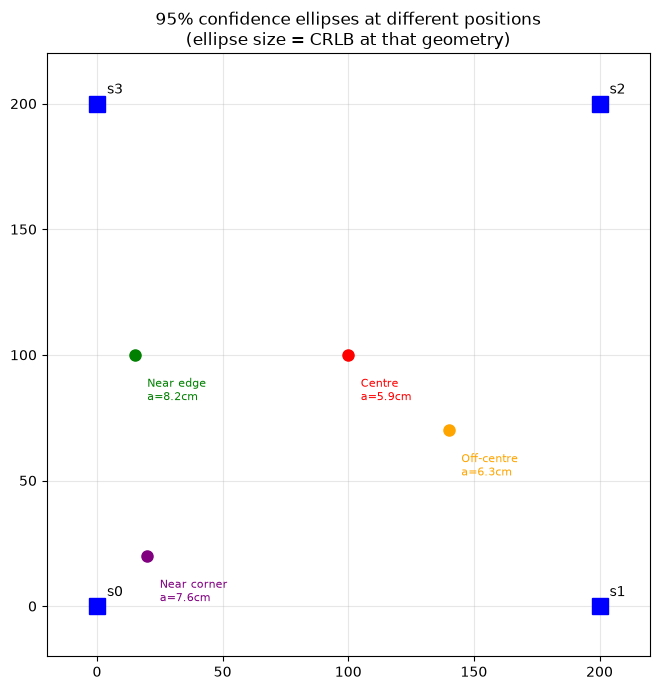

Note: ellipses are scaled up 100x for visibility at this array size


In [9]:
from engine.confidence import confidence_ellipse, CHI2_95_2DOF

def draw_ellipse(ax, center, cov, sigma_r, color='red', alpha=0.3, label=''):
    e = confidence_ellipse(cov, sigma_r)
    ellipse = Ellipse(xy=center,
                      width=2*e['a'], height=2*e['b'],
                      angle=e['angle_deg'],
                      edgecolor=color, facecolor=color,
                      alpha=alpha, linewidth=2, label=label)
    ax.add_patch(ellipse)
    return e

# Show ellipses at several positions
fig, ax = plt.subplots(figsize=(8, 7))
for i, s in enumerate(sensors):
    ax.plot(*s, 'bs', markersize=12, zorder=5)
    ax.annotate(f's{i}', xy=s, xytext=(s[0]+4, s[1]+4), fontsize=10)

colors_pos = ['red', 'green', 'purple', 'orange']
for (name, pos), col in zip(test_positions, colors_pos):
    F   = compute_fim(pos, sensors, sigma_r)
    cov = np.linalg.inv(F) / sigma_r**2   # raw cov for confidence_ellipse
    e   = draw_ellipse(ax, pos, cov, sigma_r, color=col, alpha=0.25)
    ax.plot(*pos, 'o', color=col, markersize=8, zorder=5)
    ax.annotate(f"{name}\na={e['a']*100:.1f}cm", xy=pos,
                xytext=(pos[0]+5, pos[1]-18), fontsize=8, color=col)

ax.set_xlim(-20, 220); ax.set_ylim(-20, 220)
ax.set_aspect('equal')
ax.set_title('95% confidence ellipses at different positions\n(ellipse size = CRLB at that geometry)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Note: ellipses are scaled up 100x for visibility at this array size")

---
## 7. GDOP — Geometric Dilution of Precision

### What is GDOP?

GDOP (Geometric Dilution of Precision) quantifies how sensor geometry amplifies
measurement noise into position error. A scalar summary:

$$\text{GDOP} = \sqrt{\text{tr}(\mathbf{F}^{-1})} / \sigma_r = \sqrt{\lambda_1 + \lambda_2} / \sigma_r$$

Low GDOP = good geometry = small position error for a given noise level.  
High GDOP = poor geometry = same noise gives much larger error.

### Practical implication for sensor placement

GDOP is lowest near the **centroid** of the sensor array and increases toward edges
and corners. For the real deployment this means: **the area you care most about
should be inside the sensor perimeter**, not at the edges.

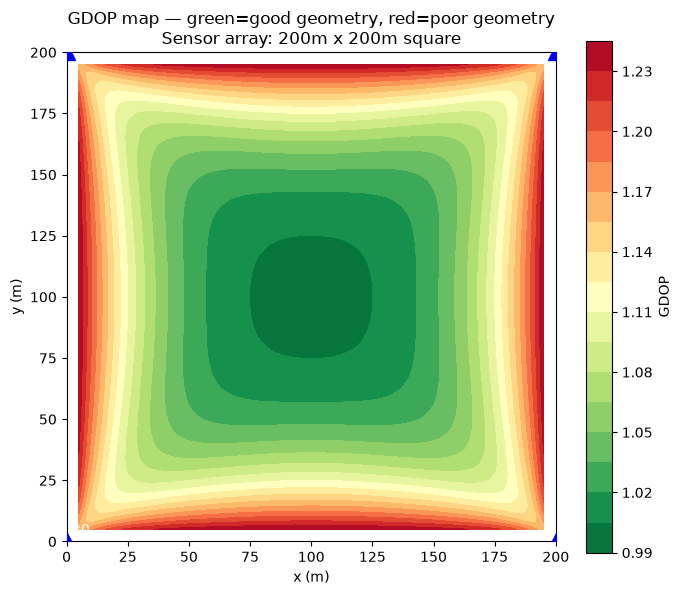

Key insight: GDOP is lowest at centre, grows toward edges and corners.
Place the area of interest near the array centroid for best accuracy.


In [10]:
# Plot GDOP map over the entire sensor array area
grid_pts = np.linspace(5, 195, 60)
GX, GY = np.meshgrid(grid_pts, grid_pts)
GDOP = np.zeros_like(GX)

for i in range(GX.shape[0]):
    for j in range(GX.shape[1]):
        pos = np.array([GX[i,j], GY[i,j]])
        try:
            F = compute_fim(pos, sensors, sigma_r)
            crlb = np.linalg.inv(F)
            GDOP[i,j] = np.sqrt(np.trace(crlb)) / sigma_r
        except:
            GDOP[i,j] = np.nan

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.contourf(GX, GY, GDOP, levels=20, cmap='RdYlGn_r')
plt.colorbar(im, ax=ax, label='GDOP')
ax.contour(GX, GY, GDOP, levels=[1.5, 2.0, 2.5, 3.0], colors='white',
           linewidths=0.8, alpha=0.7)
for i, s in enumerate(sensors):
    ax.plot(*s, 'b^', markersize=12, zorder=5)
    ax.annotate(f's{i}', xy=s, xytext=(s[0]+3, s[1]+3), fontsize=10, color='white')
ax.set_xlim(0, 200); ax.set_ylim(0, 200)
ax.set_aspect('equal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('GDOP map — green=good geometry, red=poor geometry\nSensor array: 200m x 200m square')
plt.tight_layout()
plt.show()

print("Key insight: GDOP is lowest at centre, grows toward edges and corners.")
print("Place the area of interest near the array centroid for best accuracy.")

---
## 8. Weighted Estimation as Maximum-Ratio Combining

> **Read sections 3 and 4 first.** Those showed *that* we should weight by the inverse
> noise covariance. This section is about *grip*: why that weighting is the exact same
> move you already make in a diversity receiver, and what it buys you.

### The design question

Four sensors hear the source. One is close (strong signal, clean arrival time); one is
far (weak signal, noisy arrival time). If you let every sensor's measurement count
**equally**, a noisy vote carries the same weight as a clean one. How much should you
down-weight the noisy sensor — and is there an *optimal* amount, or is it a heuristic?

### You already solved this — it is Maximum-Ratio Combining

In a diversity receiver you never average the branches. You weight each branch by its
SNR before summing, because that maximises post-combining SNR. Equal-gain combining
(plain averaging) is strictly worse, and the proof is the Cauchy–Schwarz argument you
have seen. The optimal branch weight is proportional to amplitude / noise power.

**Weighted least squares is MRC generalised to correlated, vector-valued measurements.**
The optimal weight matrix is the inverse measurement covariance $\mathbf{C}^{-1}$:

$$\hat{\mathbf{x}} = \arg\min_{\mathbf{x}}\ \mathbf{r}(\mathbf{x})^T \mathbf{C}^{-1}\,\mathbf{r}(\mathbf{x})$$

- Scalar branch SNR weighting $\;\longrightarrow\;$ matrix inverse-variance weighting.
- "Trust the strong branch more" $\;\longrightarrow\;$ "trust the low-variance sensor more."

### Where the current engine was wrong

Up to step 7 the estimator used $\mathbf{C} = \sigma^2\mathbf{M}$ — the **same** $\sigma$
for every sensor. That is **equal-gain combining**: it ignores the per-sensor SNR column
the dashboard literally displays. Fixing it means switching from equal-gain to
maximum-ratio. The per-sensor noise comes from geometry (section below): a sensor at
range $r$ sees amplitude $\propto 1/r$, so its arrival-time CRLB gives
$\sigma_\tau \propto r$ — farther sensor, noisier clock reading (DEC-009).

### Predict before you run

Below we degrade **one** sensor's noise by a factor of 1, 3, 10, 30 and compare
equal-weight LS against MRC. Before running, write down your expectation:

- Equal-weight RMSE as the bad sensor gets worse: **?**
- MRC RMSE as the bad sensor gets worse: **?**
- At what point does the difference become large — gradually, or fast?

### Break it

The last column is the "break it" experiment: a single near-dead sensor. Watch whether
MRC *degrades gracefully* (down-weights the bad branch and holds accuracy) while
equal-weight is *dragged*. The size of that gap is the grip — it is the MRC array gain,
measured in dB, in a localisation problem.

**Takeaway (in your language):** inverse-variance weighting = MRC = soft decisions.
Equal-weight LS is hard-decision / equal-gain combining — it throws away the reliability
information you are already measuring.

In [11]:
# Step 1: see the heterogeneity. Per-sensor noise comes from range (DEC-009).
from engine.tdoa import timing_std_from_range, snr_db_from_range

src_h = np.array([70.0, 130.0])
dists = np.linalg.norm(src_h - sensors, axis=1)
std_i = timing_std_from_range(dists, ref_std_s=1e-4)
snr_i = snr_db_from_range(dists)

print(f"{'sensor':<8}{'range (m)':>12}{'SNR (dB)':>12}{'timing std (us)':>18}")
print("-" * 50)
for i in range(len(sensors)):
    print(f"s{i:<7}{dists[i]:>12.1f}{snr_i[i]:>12.1f}{std_i[i]*1e6:>18.2f}")
print("\nFarther sensor -> lower SNR -> larger timing std. These are the per-sensor")
print("'branch reliabilities'. Equal-weight LS ignores this column; MRC uses it.")

sensor     range (m)    SNR (dB)   timing std (us)
--------------------------------------------------
s0             147.6        16.6            147.65
s1             183.8        14.7            183.85
s2             147.6        16.6            147.65
s3              99.0        20.1             98.99

Farther sensor -> lower SNR -> larger timing std. These are the per-sensor
'branch reliabilities'. Equal-weight LS ignores this column; MRC uses it.


In [12]:
# Step 2: MRC vs equal-weight as ONE sensor degrades (the "break it" experiment).
from engine.tdoa import compute_tdoa_measurements
from engine.localizer import GaussNewtonTDOA

src_c = np.array([100.0, 100.0])   # array centre, good geometry
base = 1e-4
loc = GaussNewtonTDOA()
n = 4000

print(f"{'sensor-1 noise':<16}{'equal RMSE (cm)':>18}{'MRC RMSE (cm)':>16}{'MRC gain (dB)':>16}")
print("-" * 66)
for factor in [1, 3, 10, 30]:
    std = np.array([base, base * factor, base, base])   # only sensor 1 degraded
    var = std ** 2
    rng = np.random.default_rng(7)
    ee = ew = 0.0
    for _ in range(n):
        t = compute_tdoa_measurements(src_c, sensors, noise_std_s=std, rng=rng)
        a, _ = loc.estimate(t, sensors)                    # equal-weight LS
        b, _ = loc.estimate(t, sensors, sensor_var=var)    # MRC (inverse-variance)
        ee += np.sum((a - src_c) ** 2)
        ew += np.sum((b - src_c) ** 2)
    ee /= n; ew /= n
    gain_db = 10 * np.log10(ee / ew)
    print(f"x{factor:<15}{100*np.sqrt(ee):>18.2f}{100*np.sqrt(ew):>16.2f}{gain_db:>16.1f}")

print("\nEqual-weight RMSE blows up as the bad sensor worsens; MRC stays flat because")
print("it down-weights the dead branch. That flat line is the grip: maximum-ratio")
print("combining is robust to a weak branch, equal-gain is not.")

sensor-1 noise     equal RMSE (cm)   MRC RMSE (cm)   MRC gain (dB)
------------------------------------------------------------------


x1                            3.39            3.39             0.0


x3                            5.84            4.39             2.5


x10                          17.11            4.79            11.1


x30                          50.68            4.83            20.4

Equal-weight RMSE blows up as the bad sensor worsens; MRC stays flat because
it down-weights the dead branch. That flat line is the grip: maximum-ratio
combining is robust to a weak branch, equal-gain is not.
